# Timeline and Key Tables

Timeline and parameter-table recipes using the shared configuration and the pump, resistance, and CT pickles exported from notebook 06.


In [20]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
project_root = next(
    (candidate for candidate in (working_directory, *working_directory.parents) if (candidate / "pyproject.toml").is_file()),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from within the basalt-processing project.")

source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from basalt_processing.paths import load_config, resolve_path

CONFIG_PATH = project_root / "config" / "basalt.example.toml"
config = load_config(CONFIG_PATH)
paths_config = config.get("paths", {})
data_root = resolve_path(paths_config["data_root"], config.get("_config_dir"))
fluid_state_root = resolve_path(paths_config["fluid_state"], data_root)
ct_processed_root = resolve_path(paths_config["ct_processed"], data_root)
ct_pretest_processed_root = resolve_path(paths_config["ct_pretest_processed"], data_root)
ct_pretest_raw_root = resolve_path(paths_config["ct_pretest_raw"], data_root)
output_root = resolve_path(paths_config["output"], data_root)
data_root, fluid_state_root, ct_processed_root, ct_pretest_processed_root, ct_pretest_raw_root, output_root


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fluid_saturation_path = fluid_state_root / "data" / "fluid_saturation.xlsx"
if not fluid_saturation_path.is_file():
    raise FileNotFoundError(f"Fluid saturation workbook not found: {fluid_saturation_path}")
fluid_saturation_data = pd.read_excel(fluid_saturation_path)
fluid_saturation_data


,fluid,from,to
0,dry,2023-02-01 09:00:00,2023-02-06 10:39:00
1,co2 (g),2023-02-06 10:39:00,2023-02-06 17:00:00
2,co2 (l),2023-02-06 17:00:00,2023-02-07 17:00:00
3,co2 (g),2023-02-07 17:00:00,2023-02-08 08:00:00
4,dry,2023-02-08 08:00:00,2023-02-08 18:00:00
5,brine,2023-02-08 18:00:00,2023-02-21 14:16:00


# Plot test timeline

Load and prepare data

In [22]:
timeline_paths = {
    "resistivity": output_root / "resistivity.pkl",
    "resistivity 1000 Hz": output_root / "resistivity_1000hz.pkl",
    "resistivity 5000 Hz": output_root / "resistivity_5000hz.pkl",
    "resistivity 10000 Hz": output_root / "resistivity_10000hz.pkl",
    "mechanical": output_root / "mechanical.pkl",
    "CT datetimes": output_root / "CT_datetimes.pkl",
}
missing_timeline_paths = [label for label, path in timeline_paths.items() if not path.is_file()]
if missing_timeline_paths:
    raise FileNotFoundError(
        f"Missing notebook 06 timeline exports: {missing_timeline_paths}. "
        "Run its timeline-pickle export cell with RUN_TIMELINE_PICKLE_EXPORT = True."
    )

resistivity_data = pd.read_pickle(timeline_paths["resistivity"])
resistivity_1000hz_data = pd.read_pickle(timeline_paths["resistivity 1000 Hz"])
resistivity_5000hz_data = pd.read_pickle(timeline_paths["resistivity 5000 Hz"])
resistivity_10000hz_data = pd.read_pickle(timeline_paths["resistivity 10000 Hz"])
mechanical_data = pd.read_pickle(timeline_paths["mechanical"])
ct_scan_datetime_data = pd.read_pickle(timeline_paths["CT datetimes"])
mechanical_data["datetime"] = pd.to_datetime(mechanical_data["datetime"])
ct_scan_datetime_data["datetime"] = pd.to_datetime(ct_scan_datetime_data["datetime"])
ct_scan_datetime_data["time"] = (
    ct_scan_datetime_data["datetime"] - mechanical_data["datetime"].iloc[0]
) / pd.Timedelta(hours=1)
if "kV" not in ct_scan_datetime_data:
    ct_scan_datetime_data["kV"] = pd.NA
ct_scan_datetime_data["kV"] = pd.to_numeric(ct_scan_datetime_data["kV"], errors="coerce")
if "Folder_Name" in ct_scan_datetime_data:
    legacy_140kv = ct_scan_datetime_data["Folder_Name"].astype(str).str.contains("kV140", case=False, na=False)
    ct_scan_datetime_data.loc[ct_scan_datetime_data["kV"].isna() & legacy_140kv, "kV"] = 140
ct_scan_datetime_data["kV"] = ct_scan_datetime_data["kV"].fillna(100)


In [23]:
# Calculate time difference in hours for the fluid saturation data
fluid_saturation_data["from_time"] = (
    fluid_saturation_data["from"] - mechanical_data["datetime"].iloc[0]
) / pd.Timedelta(hours=1)

fluid_saturation_data["to_time"] = (
    fluid_saturation_data["to"] - mechanical_data["datetime"].iloc[0]
) / pd.Timedelta(hours=1)

# Plot test timeline

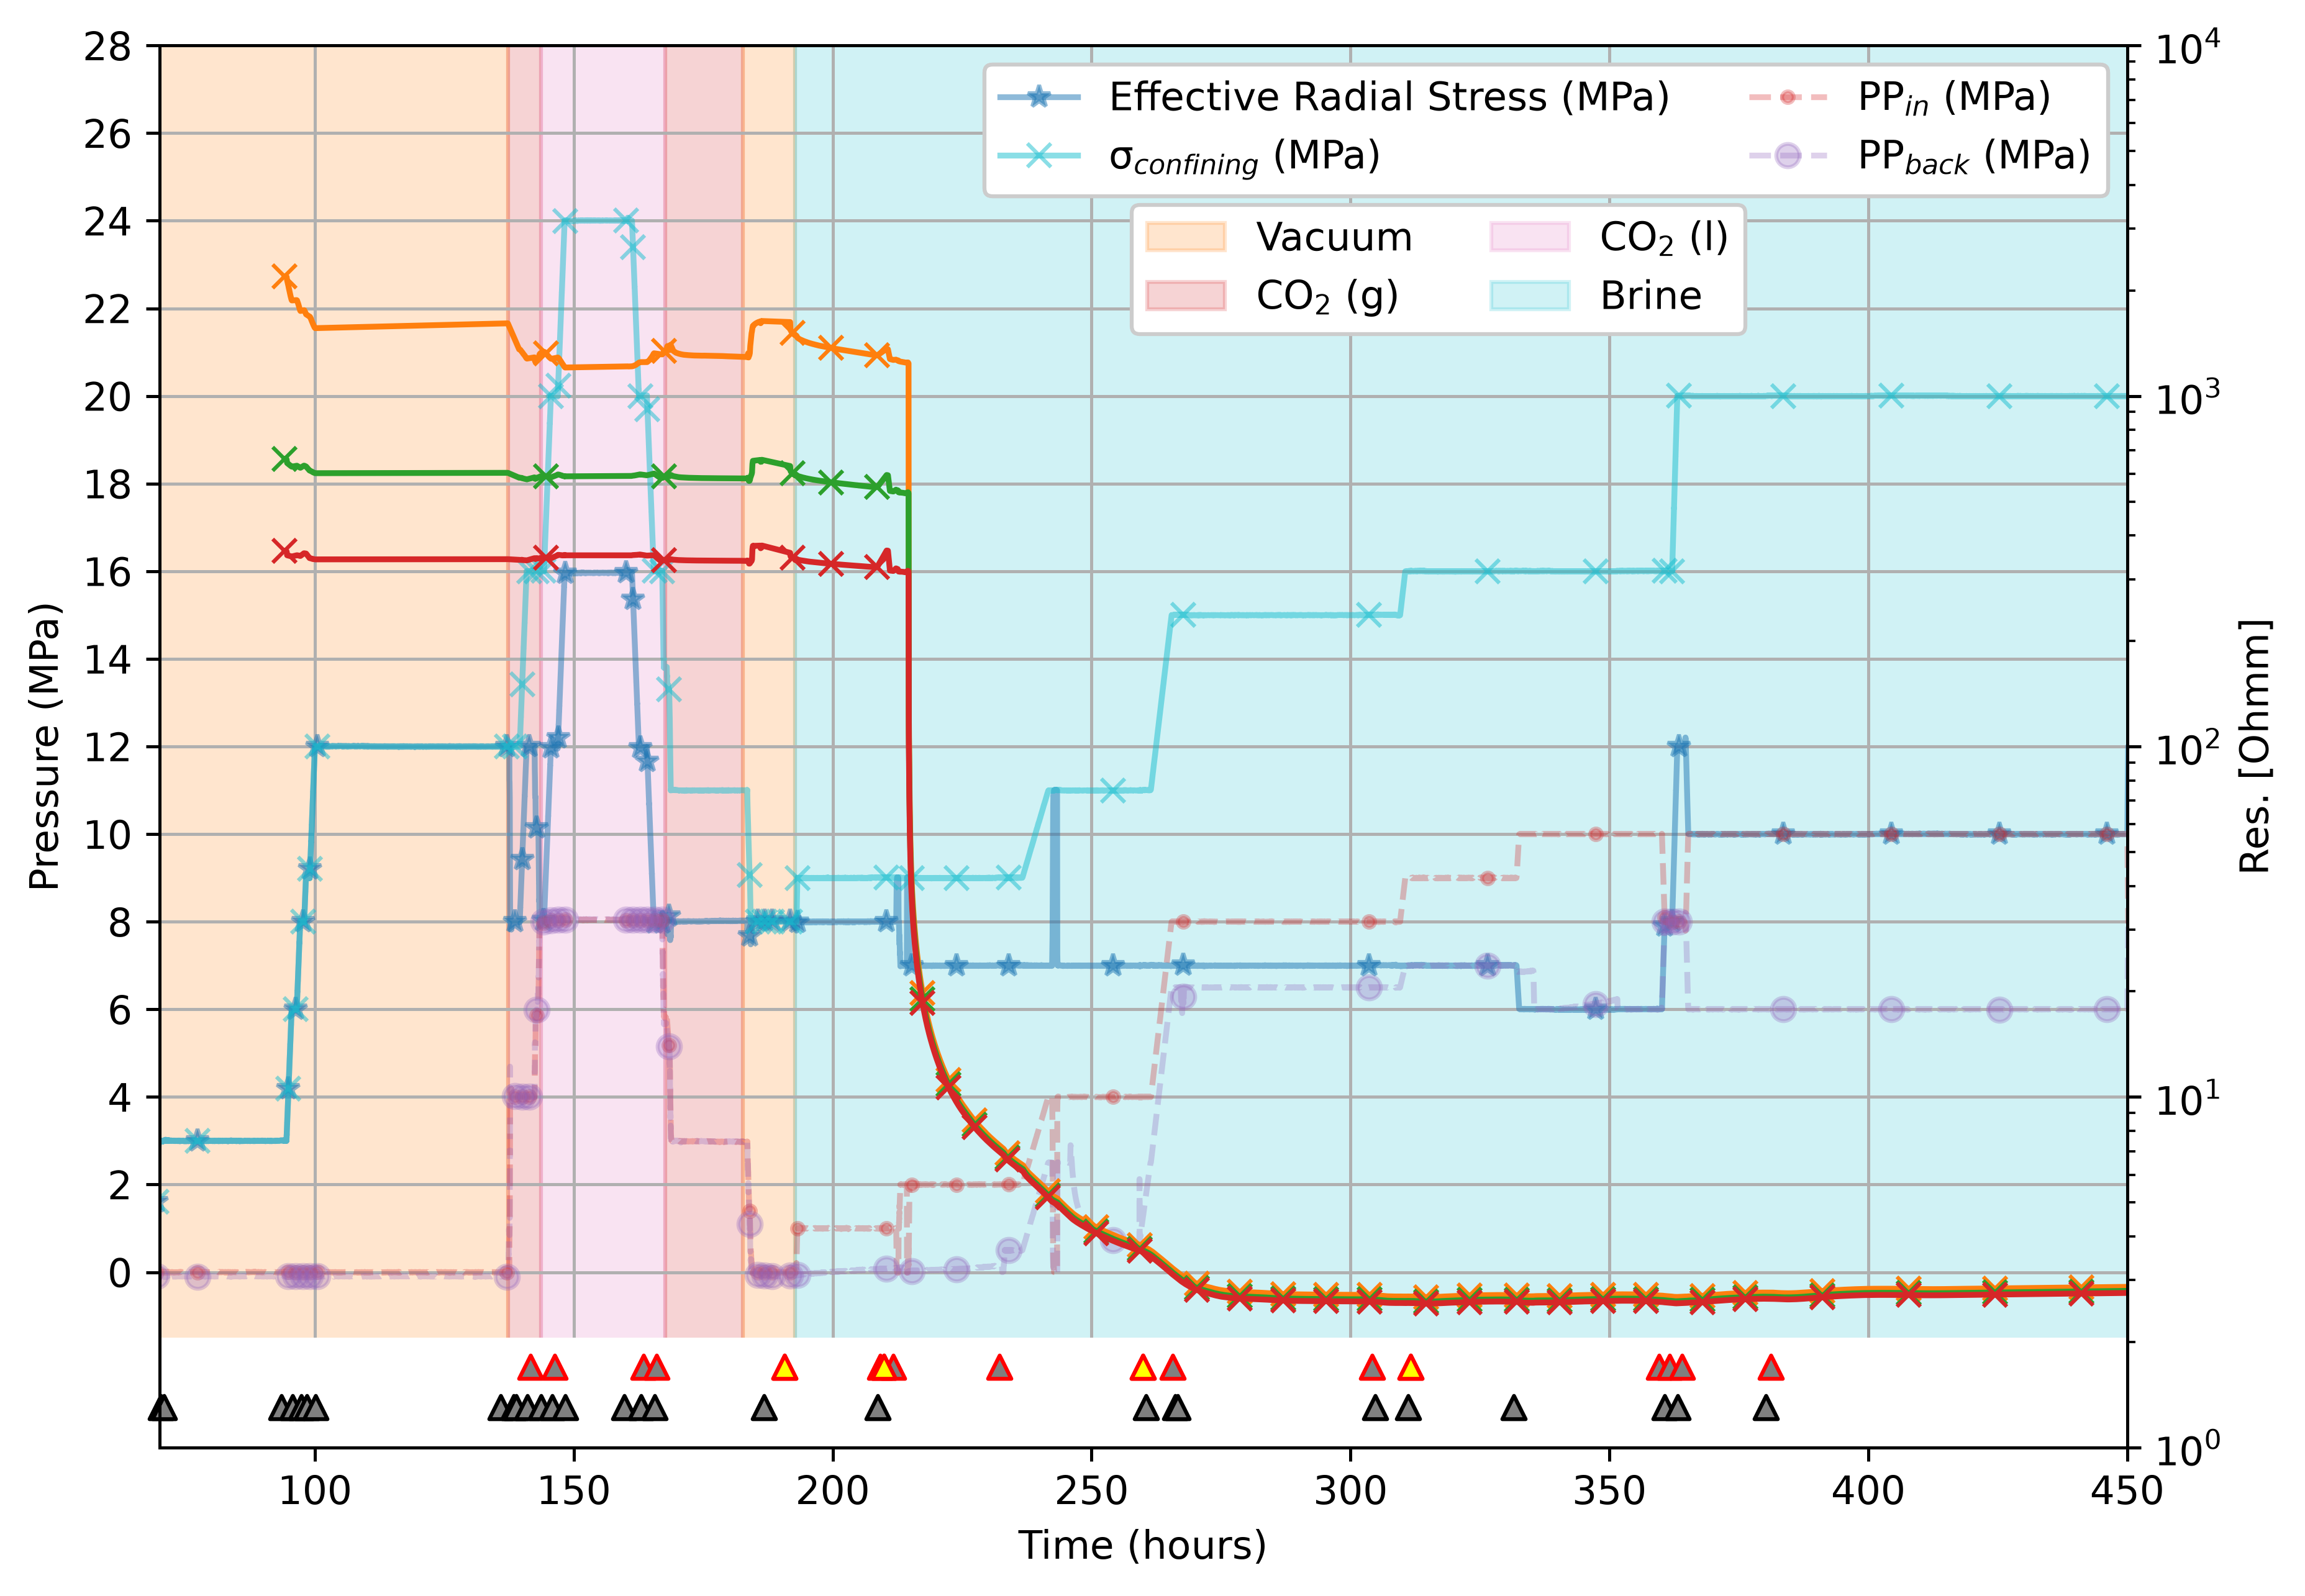

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

# Create the main figure and axis
f, ax = plt.subplots(figsize=(8.27, 11.69/2), dpi=450)  # A4 size

ax.grid()

# Define a colorblind-friendly colormap
tab10_colors = plt.cm.tab10.colors

# Plot the mechanical data
(line1,) = ax.plot(
    mechanical_data["time"].values[:],
    mechanical_data["B24   Effective Radial Stress_Calc"].values[:],
    label="Effective Radial Stress (MPa)",
    color=tab10_colors[0],
    marker="*",
    markevery=500,
    alpha=0.5
)
(line7,) = ax.plot(
    mechanical_data["time"].values[:],
    mechanical_data["B1    Cell Pressure_Calc"].values[:],
    label="σ$_{confining}$ (MPa)",
    color=tab10_colors[9],
    marker="x",
    markevery=500,
    alpha=0.5
)
(line4,) = ax.plot(
    mechanical_data["time"].values[:],
    mechanical_data["B4    Pore Pressure Bottom  PP1_Calc"].values[:],
    label="PP$_{in}$ (MPa)",
    color=tab10_colors[3],
    linestyle="--",
    marker=".",
    markevery=500,
    alpha=0.3
)
(line5,) = ax.plot(
    mechanical_data["time"].values[:],
    mechanical_data["B2    Pore Pressure Top  PP2_Calc"].values[:],
    label="PP$_{back}$ (MPa)",
    color=tab10_colors[4],
    marker="o",
    linestyle="--",
    markevery=500,
    alpha=0.3
)

# Move resistivity to the third y-axis
ax3 = ax.twinx()
ax3.spines["right"].set_position(("outward", 0))

(line2a,) = ax3.plot(
    resistivity_1000hz_data[(resistivity_1000hz_data["rho_Ch1"]>1) & (resistivity_1000hz_data["rho_Ch1"]<3000)]["time"].values,
    resistivity_1000hz_data[(resistivity_1000hz_data["rho_Ch1"]>1) & (resistivity_1000hz_data["rho_Ch1"]<3000)]["rho_Ch1"].values,
    "-",
    color=tab10_colors[1],
    label="Resistivity 1 kHz",
    marker="x",
    markevery=100
)
(line2b,) = ax3.plot(
    resistivity_5000hz_data[(resistivity_5000hz_data["rho_Ch1"]>1) & (resistivity_5000hz_data["rho_Ch1"]<1000)]["time"].values,
    resistivity_5000hz_data[(resistivity_5000hz_data["rho_Ch1"]>1) & (resistivity_5000hz_data["rho_Ch1"]<1000)]["rho_Ch1"].values,
    "-",
    color=tab10_colors[2],
    label="Resistivity 5 kHz",
    marker="x",
    markevery=100
)
(line2c,) = ax3.plot(
    resistivity_10000hz_data[(resistivity_10000hz_data["rho_Ch1"]>1) & (resistivity_10000hz_data["rho_Ch1"]<900)]["time"].values,
    resistivity_10000hz_data[(resistivity_10000hz_data["rho_Ch1"]>1) & (resistivity_10000hz_data["rho_Ch1"]<900)]["rho_Ch1"].values,
    "-",
    color=tab10_colors[3],
    label="Resistivity 10 kHz",
    marker="x",
    markevery=100
)
ax3.set_ylabel("Res. [Ohmm]", color="black")
ax3.tick_params(axis="y", colors="black")
ax3.set_yscale("log")

# Plot triangles for CT scans
ct_scan_data_100kV = ct_scan_datetime_data[ct_scan_datetime_data.kV==100].where((ct_scan_datetime_data["time"]>70)).where((ct_scan_datetime_data["time"]< 501)).dropna()
ct_scan_data_140kV = ct_scan_datetime_data[ct_scan_datetime_data.kV==140].where((ct_scan_datetime_data["time"]>70)).where((ct_scan_datetime_data["time"]< 501)).dropna()

ct_scan_marker = ax3.scatter(
    ct_scan_data_100kV["time"].values,
    [1.3] * len(ct_scan_data_100kV),
    marker="^",
    color="grey",
    edgecolor="black",
    #label="CT scan (100 kV)",
    clip_on=False,
)

ct_scan_marker = ax3.scatter(
    ct_scan_data_140kV["time"].values,
    [1.7] * len(ct_scan_data_140kV),
    marker="^",
    color="grey",
    edgecolor="red",
    #label="CT scan (140 kV)",
    clip_on=True,
    zorder = 10000
)

# Add shading depending on fluids
fluid_colors = {
    "dry": tab10_colors[1],
    "co2 (g)": tab10_colors[3],
    "co2 (l)": tab10_colors[6],
    "brine": tab10_colors[9],
}

for _, row in fluid_saturation_data.iterrows():
    ax.fill_betweenx(
        (-10, 30),
        row["from_time"],
        row["to_time"],
        color=fluid_colors[row["fluid"]],
        alpha=0.2,
    )

# Creating patches for the fluid saturation legend
fluid_patches = [
    mpatches.Patch(color=color, label=fluid.capitalize().replace("Co2", "CO$_2$").replace("Dry","Vacuum"), alpha=0.2)
    for fluid, color in fluid_colors.items()
]

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.17),
    ncol=3,
    frameon=False,
)

fluid_legend = ax.legend(handles=fluid_patches, loc="upper center", framealpha=1, ncol=2, bbox_to_anchor=(0.65, 0.9))
ax.add_artist(fluid_legend)

# Collecting the handles and labels for the unified legend
(handles, labels,) = ax.get_legend_handles_labels()

#handles = handles[-2:] + handles[:-2]
ct_legend = ax.legend(handles=handles, ncol=2, loc="upper right", framealpha=1)
ax.add_artist(ct_legend)

# Add the handles and labels from the other axes
for additional_ax in [ax3]:
    extra_handles, extra_labels = additional_ax.get_legend_handles_labels()
    handles.extend(extra_handles)
    labels.extend(extra_labels)

plt.tight_layout(rect=[0, 0, 1, 0.95])
ax.set_xlim(70, 450)
ax.set_ylim(-4, 28)
ax.set_yticks(np.arange(0, 28.2, 2))

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Pressure (MPa)")
ax3.set_ylim(1, 10000)

ax.axhspan(-4, -1.5, facecolor="white", edgecolor="none", zorder=20)


selected_CT_scans = ["20230208-160256",
                     "20230209-111213",
                     "20230211-131521",
                     "20230213-165354"]

for ct in selected_CT_scans:
    ct_data = ct_scan_data_140kV[ct_scan_data_140kV["folder_name"] == ct]
    ct_scan_marker = ax3.scatter(
        ct_data["time"].values,
        [1.7] * len(ct_data),
        marker="^",
        color="yellow",
        edgecolor="red",
        #label="CT scan (140 kV)",
        clip_on=True,
        zorder = 10000
    )

figures_root = output_root / "figures"
figures_root.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_root / "timeline-results-scientific-data.png", dpi=450)


plt.show()


In [25]:
import h5py

processed_root = ct_processed_root
ct_scan_info = []


def scan_folder_name(row):
    for column in ("folder_name", "Folder_Name", "folder"):
        value = row.get(column)
        if pd.notna(value) and str(value):
            return Path(str(value)).name
    return ""


for _, row in ct_scan_datetime_data.iterrows():
    folder_name = scan_folder_name(row)
    if not folder_name:
        print("Skipping CT row without a processed-folder name.")
        continue
    folder_path = processed_root / folder_name
    if not folder_path.exists() and processed_root.exists():
        matches = [path for path in processed_root.rglob(folder_name) if path.is_dir()]
        folder_path = matches[0] if matches else folder_path
    h5_files = sorted(folder_path.glob("*.hdf5")) if folder_path.exists() else []
    if not h5_files:
        print(f"No HDF5 files found under configured path {folder_path}.")
        continue

    h5_file = h5_files[0]
    try:
        with h5py.File(h5_file, "r") as handle:
            dataset = handle["data"] if "data" in handle else handle.get("data_masked")
            if dataset is None:
                print(f"No data dataset found in {h5_file}")
                continue
            voxel_size = dataset.attrs.get("voxel_size", None)
            voxel_size_display = voxel_size
            if isinstance(voxel_size, (list, tuple, np.ndarray)) and len(voxel_size) > 0:
                voxel_arr = np.asarray(voxel_size)
                if np.all(voxel_arr == voxel_arr.flat[0]):
                    voxel_size_display = voxel_arr.flat[0].item()
            ct_scan_info.append(
                {
                    "folder": folder_name,
                    "h5_file": h5_file.name,
                    "DOI": "",
                    "datetime": row.get("datetime"),
                    "kV": row.get("kV"),
                    "shape": dataset.shape,
                    "dtype": str(dataset.dtype),
                    "voxel_size": round(float(voxel_size_display), 6) if voxel_size_display is not None else None,
                }
            )
    except OSError as error:
        print(f"Error reading {h5_file}: {error}")

ct_info_df = pd.DataFrame(ct_scan_info)
for info in ct_scan_info:
    ct_datetime = pd.Timestamp(info["datetime"])
    closest_idx = (mechanical_data["datetime"] - ct_datetime).abs().idxmin()
    info["ct_datetime"] = ct_datetime
    info["cell_pressure"] = mechanical_data.loc[closest_idx, "B1    Cell Pressure_Calc"]
    info["pore_pressure_top"] = mechanical_data.loc[closest_idx, "B2    Pore Pressure Top  PP2_Calc"]
    info["pore_pressure_bottom"] = mechanical_data.loc[closest_idx, "B4    Pore Pressure Bottom  PP1_Calc"]
    for frequency, frame in (
        ("1000hz", resistivity_1000hz_data),
        ("5000hz", resistivity_5000hz_data),
        ("10000hz", resistivity_10000hz_data),
    ):
        if not frame.empty:
            nearest_idx = (frame["datetime"] - ct_datetime).abs().idxmin()
            info[f"resistivity_{frequency}"] = frame.loc[nearest_idx, "rho_Ch1"]
    fluid_match = fluid_saturation_data[
        (fluid_saturation_data["from"] <= ct_datetime) & (fluid_saturation_data["to"] > ct_datetime)
    ]
    info["fluid"] = fluid_match.iloc[0]["fluid"] if not fluid_match.empty else None

ct_info_df = pd.DataFrame(ct_scan_info)


In [31]:
PRETEST_ACQUISITION = "20200275-CYL11159231-1500-100kV-200uA-025mmAg_with_foam"
PRETEST_FOLDER = ct_pretest_processed_root
PRETEST_H5_PATH = PRETEST_FOLDER / f"{PRETEST_ACQUISITION}.hdf5"
PRETEST_XTEKCT_PATH = (
    ct_pretest_raw_root / "data" / f"{PRETEST_ACQUISITION}.xtekct"
)
if not PRETEST_H5_PATH.is_file() or not PRETEST_XTEKCT_PATH.is_file():
    raise FileNotFoundError(f"Pre-test CT files were not found under {PRETEST_FOLDER}")

with h5py.File(PRETEST_H5_PATH, "r") as handle:
    dataset = handle["data"] if "data" in handle else handle.get("data_masked")
    if dataset is None:
        raise KeyError(f"No data dataset found in {PRETEST_H5_PATH}")
    pretest_shape = dataset.shape
    pretest_dtype = str(dataset.dtype)
    pretest_voxel_size = dataset.attrs.get("voxel_size")

from basalt_processing.ct_inventory import xray_kv_from_xtekct
pretest_row = {
    "folder": (Path("CT") / "pre-test" / "processed").as_posix(),
    "h5_file": PRETEST_H5_PATH.name,
    "DOI": "",
    "datetime": pd.NaT,
    "kV": xray_kv_from_xtekct(PRETEST_XTEKCT_PATH),
    "shape": pretest_shape,
    "dtype": pretest_dtype,
    "voxel_size": pretest_voxel_size[0],
    "ct_datetime": pd.NaT,
    "acquisition": PRETEST_ACQUISITION,
    "scan_role": "Pre-test scan",
}

test_scan_rows = ct_info_df[ct_info_df["ct_datetime"] < pd.Timestamp("2023-02-18")].copy()
test_scan_rows["acquisition"] = test_scan_rows["h5_file"].map(lambda value: Path(value).stem)
test_scan_rows["scan_role"] = "Test scan"
ct_info_df = pd.concat([pd.DataFrame([pretest_row]), test_scan_rows.sort_values("ct_datetime")], ignore_index=True)
ct_info_df.reset_index(drop=True, inplace=True)

In [27]:
ct_info_df

,folder,h5_file,DOI,datetime,kV,shape,dtype,voxel_size,ct_datetime,acquisition,scan_role,cell_pressure,pore_pressure_top,pore_pressure_bottom,resistivity_1000hz,resistivity_5000hz,resistivity_10000hz,fluid
0,CT/pre-test/processed,20200275-CYL11159231-1500-100kV-200uA-025mmAg_...,,NaT,100.0,"(2000, 2000, 2000)",uint16,"[0.0405326, 0.0405326, 0.0405326]",NaT,20200275-CYL11159231-1500-100kV-200uA-025mmAg_...,Pre-test scan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20230203-125454,20200275_11159231_CP1_PP0_PF0.hdf5,,2023-02-03 12:54:54,100.0,"(1999, 1250, 1250)",uint16,0.031253,2023-02-03 12:54:54,20200275_11159231_CP1_PP0_PF0,Test scan,0.999761,-0.092076,-0.000687,2192.478329,661.956518,361.647589,dry
2,20230203-153325,20200275_11159231_CP3_PP0_PF0.hdf5,,2023-02-03 15:33:25,100.0,"(2000, 1250, 1250)",uint16,0.031253,2023-02-03 15:33:25,20200275_11159231_CP3_PP0_PF0,Test scan,2.991571,-0.095488,-0.000687,2192.478329,661.956518,361.647589,dry
3,20230203-161234,20200275_11159231_CP3_PP0_PF0.hdf5,,2023-02-03 16:12:34,100.0,"(1999, 1249, 1249)",uint16,0.031253,2023-02-03 16:12:34,20200275_11159231_CP3_PP0_PF0,Test scan,2.996098,-0.091508,-0.002388,2192.478329,661.956518,361.647589,dry
4,20230204-145134,20200275_11159231_CP3_PP0_PF0.hdf5,,2023-02-04 14:51:34,100.0,"(2000, 1250, 1250)",uint16,0.031252,2023-02-04 14:51:34,20200275_11159231_CP3_PP0_PF0,Test scan,3.004020,-0.092076,-0.003522,2192.478329,661.956518,361.647589,dry
5,20230204-165728,20200275_11159231_CP6_PP0_PF0.hdf5,,2023-02-04 16:57:28,100.0,"(2000, 1250, 1250)",uint16,0.031252,2023-02-04 16:57:28,20200275_11159231_CP6_PP0_PF0,Test scan,5.993998,-0.092076,-0.001254,1873.284878,628.389397,348.382712,dry
6,20230204-183650,20200275_11159231_CP8_PP0_PF0.hdf5,,2023-02-04 18:36:50,100.0,"(2000, 1250, 1250)",uint16,0.031252,2023-02-04 18:36:50,20200275_11159231_CP8_PP0_PF0,Test scan,7.992598,-0.096626,0.001581,1747.563881,624.115529,349.687342,dry
7,20230204-194149,20200275_11159231_CP9_PP0_PF0.hdf5,,2023-02-04 19:41:49,100.0,"(2000, 1250, 1250)",uint16,0.031252,2023-02-04 19:41:49,20200275_11159231_CP9_PP0_PF0,Test scan,8.990767,-0.089802,-0.002955,1709.906311,629.238659,355.077932,dry
8,20230204-212852,20200275_11159231_CP12_PP0_PF0.hdf5,,2023-02-04 21:28:52,100.0,"(2000, 1250, 1250)",uint16,0.031252,2023-02-04 21:28:52,20200275_11159231_CP12_PP0_PF0,Test scan,11.996024,-0.096057,-0.000687,1561.474311,602.132216,341.797095,dry
9,20230206-090828,20200275_11159231_CP12_PP0_PF0.hdf5,,2023-02-06 09:08:28,100.0,"(2000, 1250, 1250)",uint16,0.031253,2023-02-06 09:08:28,20200275_11159231_CP12_PP0_PF0,Test scan,11.994892,-0.101744,-0.014294,1611.325298,603.531610,342.203958,dry
